In [9]:
%pip install matplotlib rebound numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

paths = {
    "0°": r"\\wsl.localhost\Ubuntu-24.04\home\noro113\rebound\examples\selfgravity_disc\results_0deg.txt",
    "45°": r"\\wsl.localhost\Ubuntu-24.04\home\noro113\rebound\examples\selfgravity_disc\results_45deg.txt",
    "90°": r"\\wsl.localhost\Ubuntu-24.04\home\noro113\rebound\examples\selfgravity_disc\results_90deg.txt"
}

data = {}
for label, path in paths.items():
    rows = []
    with open(path) as f:
        for line in f:
            s = line.strip()
            if not s or s.startswith("#") or s.startswith("REBOUND"):
                continue
            vals = s.split()
            if len(vals) >= 14:
                rows.append([float(x) for x in vals[:14]])
    data[label] = np.asarray(rows)

# Columns: t=0, f_core=4, R_all=5, z_all=6, R_core=7, z_core=8
plot_info = [
    (6, r"$z_{\rm rms,all}$", "Global Vertical Disturbance", "corrected_z_rms_all.png"),
    (8, r"$z_{\rm rms,core}$", "Central Disk Vertical Thickness", "corrected_z_rms_core.png"),
    (5, r"$R_{\rm rms,all}$", "Global Radial Extent", "corrected_R_rms_all.png"),
    (4, r"$f_{\rm core}$", "Core Particle Fraction", "corrected_f_core.png"),
]
output_folder = r"\\wsl.localhost\Ubuntu-24.04\home\noro113\rebound\examples\selfgravity_disc"

for col, ylabel, title, filename in plot_info:
    plt.figure(figsize=(8,5))

    for label, a in data.items():
        y = a[:, col].copy()

        if col == 8:
            y[y < 0] = np.nan

        plt.plot(a[:,0], y, label=label)

    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    plt.savefig(output_folder + "\\" + filename, dpi=200)
    plt.show()

print("Inclination runs:")
for label, a in data.items():
    valid = a[:,8] >= 0
    print(
        f"{label}: {len(a)} points, t={a[0,0]:.3f}–{a[-1,0]:.3f}; "
        f"max z_all={a[:,6].max():.4f}; "
        f"max z_core={a[valid,8].max():.4f}; "
        f"final f_core={a[-1,4]:.4f}; "
        f"final R_all={a[-1,5]:.4f}"
    )


In [7]:
import numpy as np
from pathlib import Path

# ============================================================
# SETTINGS
# ============================================================

# Folder containing the REBOUND result files
folder = Path(
    r"\\wsl.localhost\Ubuntu-24.04\home\noro113\rebound\examples\selfgravity_disc"
)

# Simulation files
files = {
    "0°": folder / "results_0deg.txt",
    "45°": folder / "results_45deg.txt",
    "90°": folder / "results_90deg.txt",
}

# Time interval over which to calculate post-encounter averages
t_start = 70.0
t_end = 100.0


# ============================================================
# COLUMN DEFINITIONS
# ============================================================

# Columns in the REBOUND heartbeat output:
#
# 0   t
# 1   N_primary_present
# 2   f_primary_present
# 3   N_core
# 4   f_core
# 5   R_rms_all
# 6   z_rms_all
# 7   R_rms_core
# 8   z_rms_core
# 9   z_core_cm
# 10  E
# 11  Lz_all
# 12  x_cm
# 13  z_cm


# ============================================================
# LOAD DATA
# ============================================================

def load_data(filename):

    rows = []

    with open(filename, "r") as f:

        for line in f:

            line = line.strip()

            # Ignore blank lines and REBOUND startup message
            if not line:
                continue

            if line.startswith("#"):
                continue

            if line.startswith("REBOUND"):
                continue

            values = line.split()

            # Make sure this is a heartbeat data line
            if len(values) >= 14:
                rows.append([float(x) for x in values[:14]])

    return np.array(rows)


# ============================================================
# CALCULATE AVERAGES
# ============================================================

results = {}

for inclination, filename in files.items():

    data = load_data(filename)

    # Select desired time interval
    mask = (
        (data[:, 0] >= t_start)
        & (data[:, 0] <= t_end)
    )

    selected = data[mask]

    if len(selected) == 0:
        print(f"No data found for {inclination}")
        continue

    # Calculate averages
    avg_z_all = np.mean(selected[:, 6])
    avg_z_core = np.mean(selected[:, 8])
    avg_R_all = np.mean(selected[:, 5])
    avg_R_core = np.mean(selected[:, 7])
    avg_f_core = np.mean(selected[:, 4])

    # Also calculate standard deviations
    std_z_all = np.std(selected[:, 6])
    std_z_core = np.std(selected[:, 8])
    std_R_all = np.std(selected[:, 5])
    std_R_core = np.std(selected[:, 7])
    std_f_core = np.std(selected[:, 4])

    results[inclination] = {
        "z_all": avg_z_all,
        "z_all_std": std_z_all,

        "z_core": avg_z_core,
        "z_core_std": std_z_core,

        "R_all": avg_R_all,
        "R_all_std": std_R_all,

        "R_core": avg_R_core,
        "R_core_std": std_R_core,

        "f_core": avg_f_core,
        "f_core_std": std_f_core,

        "N": len(selected),
    }


# ============================================================
# PRINT RESULTS
# ============================================================

print()
print("=" * 75)
print("POST-ENCOUNTER AVERAGES")
print("=" * 75)

print(f"Time interval: {t_start} <= t <= {t_end}")
print()

print(
    f"{'Inclination':<12}"
    f"{'<z_all>':>12}"
    f"{'<z_core>':>12}"
    f"{'<R_all>':>12}"
    f"{'<R_core>':>12}"
    f"{'<f_core>':>12}"
)

print("-" * 75)

for inclination in ["0°", "45°", "90°"]:

    r = results[inclination]

    print(
        f"{inclination:<12}"
        f"{r['z_all']:>12.4f}"
        f"{r['z_core']:>12.4f}"
        f"{r['R_all']:>12.4f}"
        f"{r['R_core']:>12.4f}"
        f"{r['f_core']:>12.4f}"
    )

print()
print("=" * 75)
print("STANDARD DEVIATIONS")
print("=" * 75)

print(
    f"{'Inclination':<12}"
    f"{'z_all':>12}"
    f"{'z_core':>12}"
    f"{'R_all':>12}"
    f"{'R_core':>12}"
    f"{'f_core':>12}"
)

print("-" * 75)

for inclination in ["0°", "45°", "90°"]:

    r = results[inclination]

    print(
        f"{inclination:<12}"
        f"{r['z_all_std']:>12.4f}"
        f"{r['z_core_std']:>12.4f}"
        f"{r['R_all_std']:>12.4f}"
        f"{r['R_core_std']:>12.4f}"
        f"{r['f_core_std']:>12.4f}"
    )

print()
print(f"Number of data points used:")
for inclination in ["0°", "45°", "90°"]:
    print(f"  {inclination}: {results[inclination]['N']}")


POST-ENCOUNTER AVERAGES
Time interval: 70.0 <= t <= 100.0

Inclination      <z_all>    <z_core>     <R_all>    <R_core>    <f_core>
---------------------------------------------------------------------------
0°                3.1452      0.1341      7.9579      1.5212      0.5261
45°               0.7024      0.1343      2.9503      1.6306      0.6368
90°               0.2582      0.1004      2.8602      1.6252      0.6407

STANDARD DEVIATIONS
Inclination        z_all      z_core       R_all      R_core      f_core
---------------------------------------------------------------------------
0°                0.2717      0.0300      0.0939      0.0125      0.0041
45°               0.0408      0.0107      0.0639      0.0063      0.0039
90°               0.0103      0.0024      0.0218      0.0076      0.0045

Number of data points used:
  0°: 30
  45°: 30
  90°: 30


Plot avg v inc


POST-ENCOUNTER AVERAGES
Time interval: 70.0 <= t <= 100.0

 Inclination     <z_all>    <z_core>     <R_all>    <R_core>    <f_core>
----------------------------------------------------------------------
           0      3.1452      0.1341      7.9579      1.5212      0.5261
          45      0.7024      0.1343      2.9503      1.6306      0.6368
          90      0.2582      0.1004      2.8602      1.6252      0.6407


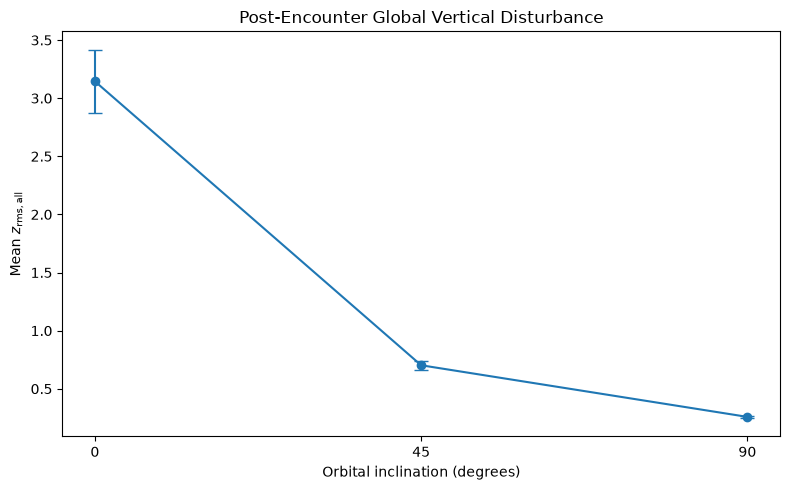

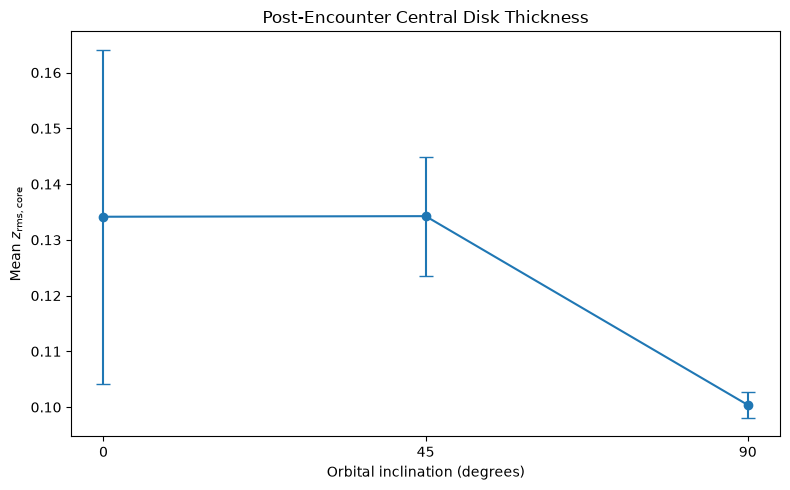

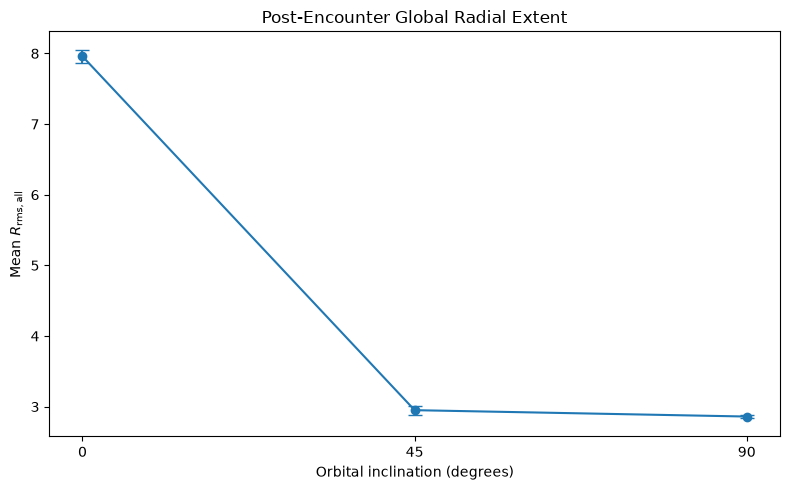

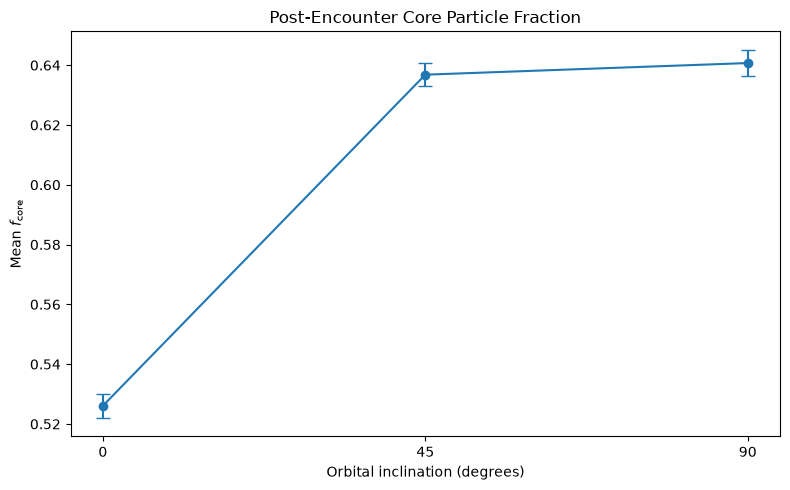


Plots saved to:
\\wsl.localhost\Ubuntu-24.04\home\noro113\rebound\examples\selfgravity_disc


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# SETTINGS
# ============================================================

# Folder containing the REBOUND result files
folder = Path(
    r"\\wsl.localhost\Ubuntu-24.04\home\noro113\rebound\examples\selfgravity_disc"
)

# Simulation files
files = {
    0: folder / "results_0deg.txt",
    45: folder / "results_45deg.txt",
    90: folder / "results_90deg.txt",
}

# Post-encounter time interval
t_start = 70.0
t_end = 100.0


# ============================================================
# LOAD REBOUND DATA
# ============================================================

def load_data(filename):

    rows = []

    with open(filename, "r") as f:

        for line in f:

            line = line.strip()

            # Ignore blank lines
            if not line:
                continue

            # Ignore comments
            if line.startswith("#"):
                continue

            # Ignore REBOUND startup message
            if line.startswith("REBOUND"):
                continue

            values = line.split()

            if len(values) >= 14:
                rows.append([float(x) for x in values[:14]])

    return np.array(rows)


# ============================================================
# CALCULATE AVERAGES AND STANDARD DEVIATIONS
# ============================================================

inclinations = []
z_all_mean = []
z_all_std = []

z_core_mean = []
z_core_std = []

R_all_mean = []
R_all_std = []

R_core_mean = []
R_core_std = []

f_core_mean = []
f_core_std = []


for inclination, filename in files.items():

    data = load_data(filename)

    # Select post-encounter interval
    mask = (
        (data[:, 0] >= t_start)
        & (data[:, 0] <= t_end)
    )

    selected = data[mask]

    if len(selected) == 0:
        print(f"No data found for {inclination} degrees")
        continue

    inclinations.append(inclination)

    # --------------------------------------------------------
    # Global vertical disturbance
    # --------------------------------------------------------

    z_all_mean.append(np.mean(selected[:, 6]))
    z_all_std.append(np.std(selected[:, 6]))

    # --------------------------------------------------------
    # Core vertical thickness
    # --------------------------------------------------------

    # Ignore invalid values (-1)
    valid_core = selected[:, 8] >= 0

    z_core_mean.append(
        np.mean(selected[valid_core, 8])
    )

    z_core_std.append(
        np.std(selected[valid_core, 8])
    )

    # --------------------------------------------------------
    # Global radial extent
    # --------------------------------------------------------

    R_all_mean.append(np.mean(selected[:, 5]))
    R_all_std.append(np.std(selected[:, 5]))

    # --------------------------------------------------------
    # Core radial extent
    # --------------------------------------------------------

    R_core_mean.append(np.mean(selected[:, 7]))
    R_core_std.append(np.std(selected[:, 7]))

    # --------------------------------------------------------
    # Core particle fraction
    # --------------------------------------------------------

    f_core_mean.append(np.mean(selected[:, 4]))
    f_core_std.append(np.std(selected[:, 4]))


# Convert lists to arrays
inclinations = np.array(inclinations)

z_all_mean = np.array(z_all_mean)
z_all_std = np.array(z_all_std)

z_core_mean = np.array(z_core_mean)
z_core_std = np.array(z_core_std)

R_all_mean = np.array(R_all_mean)
R_all_std = np.array(R_all_std)

R_core_mean = np.array(R_core_mean)
R_core_std = np.array(R_core_std)

f_core_mean = np.array(f_core_mean)
f_core_std = np.array(f_core_std)


# ============================================================
# PRINT VALUES
# ============================================================

print()
print("=" * 70)
print("POST-ENCOUNTER AVERAGES")
print("=" * 70)

print(f"Time interval: {t_start} <= t <= {t_end}")
print()

print(
    f"{'Inclination':>12}"
    f"{'<z_all>':>12}"
    f"{'<z_core>':>12}"
    f"{'<R_all>':>12}"
    f"{'<R_core>':>12}"
    f"{'<f_core>':>12}"
)

print("-" * 70)

for i in range(len(inclinations)):

    print(
        f"{inclinations[i]:>12.0f}"
        f"{z_all_mean[i]:>12.4f}"
        f"{z_core_mean[i]:>12.4f}"
        f"{R_all_mean[i]:>12.4f}"
        f"{R_core_mean[i]:>12.4f}"
        f"{f_core_mean[i]:>12.4f}"
    )


# ============================================================
# PLOT 1: GLOBAL VERTICAL DISTURBANCE
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    inclinations,
    z_all_mean,
    yerr=z_all_std,
    marker="o",
    linestyle="-",
    capsize=5
)

plt.xlabel("Orbital inclination (degrees)")
plt.ylabel(r"Mean $z_{\rm rms,all}$")
plt.title("Post-Encounter Global Vertical Disturbance")

plt.xticks([0, 45, 90])

plt.tight_layout()

plt.savefig(
    folder / "average_z_rms_all_vs_inclination.png",
    dpi=300
)

plt.show()


# ============================================================
# PLOT 2: CENTRAL DISK THICKNESS
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    inclinations,
    z_core_mean,
    yerr=z_core_std,
    marker="o",
    linestyle="-",
    capsize=5
)

plt.xlabel("Orbital inclination (degrees)")
plt.ylabel(r"Mean $z_{\rm rms,core}$")
plt.title("Post-Encounter Central Disk Thickness")

plt.xticks([0, 45, 90])

plt.tight_layout()

plt.savefig(
    folder / "average_z_rms_core_vs_inclination.png",
    dpi=300
)

plt.show()


# ============================================================
# PLOT 3: GLOBAL RADIAL EXTENT
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    inclinations,
    R_all_mean,
    yerr=R_all_std,
    marker="o",
    linestyle="-",
    capsize=5
)

plt.xlabel("Orbital inclination (degrees)")
plt.ylabel(r"Mean $R_{\rm rms,all}$")
plt.title("Post-Encounter Global Radial Extent")

plt.xticks([0, 45, 90])

plt.tight_layout()

plt.savefig(
    folder / "average_R_rms_all_vs_inclination.png",
    dpi=300
)

plt.show()


# ============================================================
# PLOT 4: CORE PARTICLE FRACTION
# ============================================================

plt.figure(figsize=(8, 5))

plt.errorbar(
    inclinations,
    f_core_mean,
    yerr=f_core_std,
    marker="o",
    linestyle="-",
    capsize=5
)

plt.xlabel("Orbital inclination (degrees)")
plt.ylabel(r"Mean $f_{\rm core}$")
plt.title("Post-Encounter Core Particle Fraction")

plt.xticks([0, 45, 90])

plt.tight_layout()

plt.savefig(
    folder / "average_f_core_vs_inclination.png",
    dpi=300
)

plt.show()


print()
print("Plots saved to:")
print(folder)